## Strategy Overview

### The Approach
This strategy uses **K-Means clustering** to group S&P 500 stocks with similar characteristics, then selects the **top momentum stocks within each cluster** for a long-only portfolio.

**Core Logic:**
1. **Cluster stocks** into 5 groups based on 19 features (technical indicators, momentum, Fama-French factors)
2. **Rank stocks** within each cluster by 3-month momentum
3. **Go long** top 5 stocks per cluster (~25 positions total)
4. **Rebalance** monthly

**Why This Works:**
- Clustering groups similar stocks together (growth vs value, high-beta vs low-beta, etc.)
- Momentum ranking identifies the strongest performers *within their peer group*
- We capture momentum while maintaining diversification across different market regimes


# Long-Only Momentum Strategy Analysis

Analyze and visualize the performance of the long-only momentum within clusters strategy.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src directory to path
sys.path.insert(0, str(Path('../src').resolve()))

# Import the strategy functions
from long_only_strategy import backtest_long_only, performance_summary

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

%matplotlib inline


### Feature Set (19 Features)

Our clustering algorithm uses three categories of features:

**1. Technical Indicators (7 features)**
- Garman-Klass Volatility, RSI, MACD, ATR
- Bollinger Bands (low, mid, high)
- Dollar Volume Rank (liquidity measure)

**2. Momentum Signals (6 features)**
- Past returns: 1m, 2m, 3m, 6m, 9m, 12m

**3. Fama-French Factor Exposures (5 features)**
- Market beta, Size (SMB), Value (HML), Profitability (RMW), Investment (CMA)

All features are **cross-sectionally z-scored** each month to ensure stock-relative comparisons.

## 1. Load Strategy Results

In [17]:
data_dir = Path('../data')

# Choose clustering method
method = 'kmeans'

# Option 1: Load pre-computed results
try:
    results = pd.read_csv(data_dir / f'long_only_results_{method}.csv', parse_dates=['Date'], index_col='Date')
    positions = pd.read_csv(data_dir / f'long_only_positions_{method}.csv', parse_dates=['Date'])
    positions = positions.set_index(['Date', 'Ticker']).sort_index()
    print("✓ Loaded pre-computed results")
except FileNotFoundError:
    # Option 2: Run backtest in notebook
    print("Running backtest in notebook...")
    clustered_data = pd.read_csv(data_dir / f'clustered_{method}.csv', parse_dates=['Date'])
    clustered_data = clustered_data.set_index(['Date', 'Ticker']).sort_index()
    
    results, positions = backtest_long_only(
        data=clustered_data,
        momentum_feature='return_3m',
        top_n=5,
    )

print(f"\nStrategy Results: {len(results)} months")
print(f"Total Positions: {len(positions)}")
print(f"Date Range: {results.index.min()} to {results.index.max()}")

Running backtest in notebook...

BACKTESTING LONG-ONLY MOMENTUM WITHIN CLUSTERS
Momentum signal: return_3m
Long top 5 stocks per cluster

Calculating forward returns...
Generating trading signals...
Calculating portfolio returns...

Strategy Results: 85 months
Total Positions: 1605
Date Range: 2018-10-31 00:00:00 to 2025-10-31 00:00:00


## 2. Performance Overview

In [18]:
# Print summary statistics
performance_summary(results)


PERFORMANCE SUMMARY

Returns Statistics:
  Total months:        85
  Mean return:            2.14%
  Median return:          2.59%
  Std deviation:          5.32%
  Min return:            -8.84%
  Max return:            17.88%

Risk-Adjusted Metrics:
  Sharpe ratio (ann):      1.39
  Win rate:              69.41%
  Cumulative return:    440.22%
  Annualized return:     26.89%
  Max drawdown:         -17.17%

Position Statistics:
  Avg positions/month:     18.6




## 3. S&P 500 Benchmark Comparison

### Strategy Mechanics

**Monthly Process:**
1. Take month-end snapshot of all features
2. Apply K-Means to cluster stocks into 5 groups
3. Within each cluster, rank by 3-month momentum (`return_3m`)
4. Long top 5 stocks per cluster (equal-weighted)
5. Hold for 1 month, then repeat

**Universe Selection:**
- Top 150 stocks by dollar volume (liquidity filter)
- Minimum 36 months of history
- Rolling selection prevents survivorship bias

**Position Sizing:**
- Equal-weighted: ~4% per stock
- ~25 total positions (5 clusters × 5 stocks)
- Maximum 20% exposure per cluster

In [26]:
import yfinance as yf

# Download S&P 500 data
print("Downloading S&P 500 benchmark data...")
spy = yf.download('SPY', start=results.index.min(), end=results.index.max(), progress=False)

# Handle MultiIndex columns
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.droplevel(1)

# Calculate monthly returns (use 'adj close' with lowercase and space)
spy_monthly = spy['Close'].resample('ME').last()
spy_returns = spy_monthly.pct_change().dropna()

# Align dates with strategy (convert both to month-end)
spy_returns.index = spy_returns.index.to_period('M').to_timestamp('M')
strategy_dates = results.index.to_period('M').to_timestamp('M')

common_dates = strategy_dates.intersection(spy_returns.index)
strategy_returns = results.loc[results.index.isin(common_dates), 'portfolio_return']
strategy_returns.index = strategy_returns.index.to_period('M').to_timestamp('M')
benchmark_returns = spy_returns.loc[common_dates]

print(f"\n{'='*80}")
print("STRATEGY vs S&P 500 COMPARISON")
print(f"{'='*80}")
print(f"Comparing {len(common_dates)} months of data")

# Calculate metrics for both
metrics_comparison = pd.DataFrame({
    'Strategy': [
        strategy_returns.mean(),
        strategy_returns.mean() * 12,
        strategy_returns.std() * np.sqrt(12),
        strategy_returns.mean() / strategy_returns.std() * np.sqrt(12),
        (strategy_returns > 0).mean(),
        (1 + strategy_returns).prod() - 1,
    ],
    'S&P 500': [
        benchmark_returns.mean(),
        benchmark_returns.mean() * 12,
        benchmark_returns.std() * np.sqrt(12),
        benchmark_returns.mean() / benchmark_returns.std() * np.sqrt(12),
        (benchmark_returns > 0).mean(),
        (1 + benchmark_returns).prod() - 1,
    ]
}, index=['Mean Monthly Return', 'Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 'Win Rate', 'Cumulative Return'])

metrics_comparison['Difference'] = metrics_comparison['Strategy'] - metrics_comparison['S&P 500']

print("\n" + metrics_comparison.to_string())

# Outperformance
alpha = strategy_returns.mean() - benchmark_returns.mean()
print(f"\n{'='*80}")
print(f"Monthly Alpha: {alpha:.2%}")
print(f"Annualized Alpha: {alpha * 12:.2%}")
print(f"{'='*80}")


STRATEGY vs S&P 500 COMPARISON
Comparing 84 months of data

                       Strategy   S&P 500  Difference
Mean Monthly Return    0.021264  0.013536    0.007729
Annualized Return      0.255172  0.162429    0.092743
Annualized Volatility  0.185402  0.170100    0.015302
Sharpe Ratio           1.376320  0.954903    0.421417
Win Rate               0.690476  0.666667    0.023810
Cumulative Return      4.225972  1.801243    2.424728

Monthly Alpha: 0.77%
Annualized Alpha: 9.27%


C:\Users\15126\AppData\Local\Temp\ipykernel_37388\1982634750.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start=results.index.min(), end=results.index.max(), progress=False)


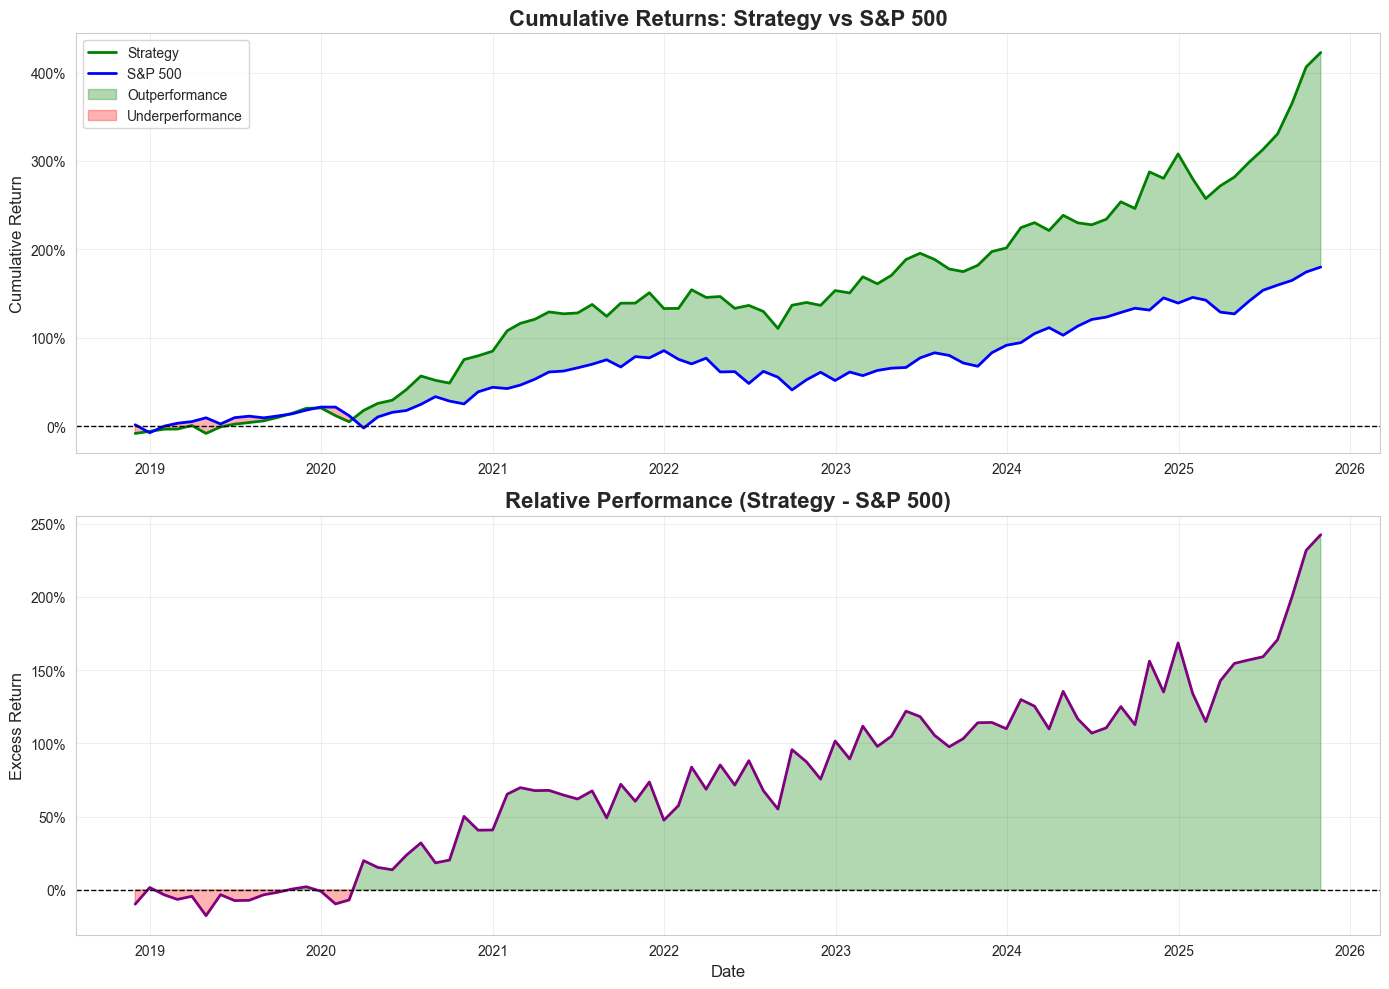

Final Outperformance: 242.47%


In [27]:
# Cumulative returns comparison
strategy_cum = (1 + strategy_returns).cumprod() - 1
benchmark_cum = (1 + benchmark_returns).cumprod() - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Cumulative returns
axes[0].plot(strategy_cum.index, strategy_cum, label='Strategy', linewidth=2, color='green')
axes[0].plot(benchmark_cum.index, benchmark_cum, label='S&P 500', linewidth=2, color='blue')
axes[0].fill_between(strategy_cum.index, strategy_cum, benchmark_cum, 
                      where=(strategy_cum >= benchmark_cum), interpolate=True, 
                      alpha=0.3, color='green', label='Outperformance')
axes[0].fill_between(strategy_cum.index, strategy_cum, benchmark_cum, 
                      where=(strategy_cum < benchmark_cum), interpolate=True, 
                      alpha=0.3, color='red', label='Underperformance')
axes[0].set_title('Cumulative Returns: Strategy vs S&P 500', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Cumulative Return', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)

# Relative performance (strategy - benchmark)
relative_perf = strategy_cum - benchmark_cum
axes[1].plot(relative_perf.index, relative_perf, linewidth=2, color='purple')
axes[1].fill_between(relative_perf.index, 0, relative_perf, 
                      where=(relative_perf >= 0), interpolate=True, alpha=0.3, color='green')
axes[1].fill_between(relative_perf.index, 0, relative_perf, 
                      where=(relative_perf < 0), interpolate=True, alpha=0.3, color='red')
axes[1].set_title('Relative Performance (Strategy - S&P 500)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Excess Return', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

print(f"Final Outperformance: {relative_perf.iloc[-1]:.2%}")

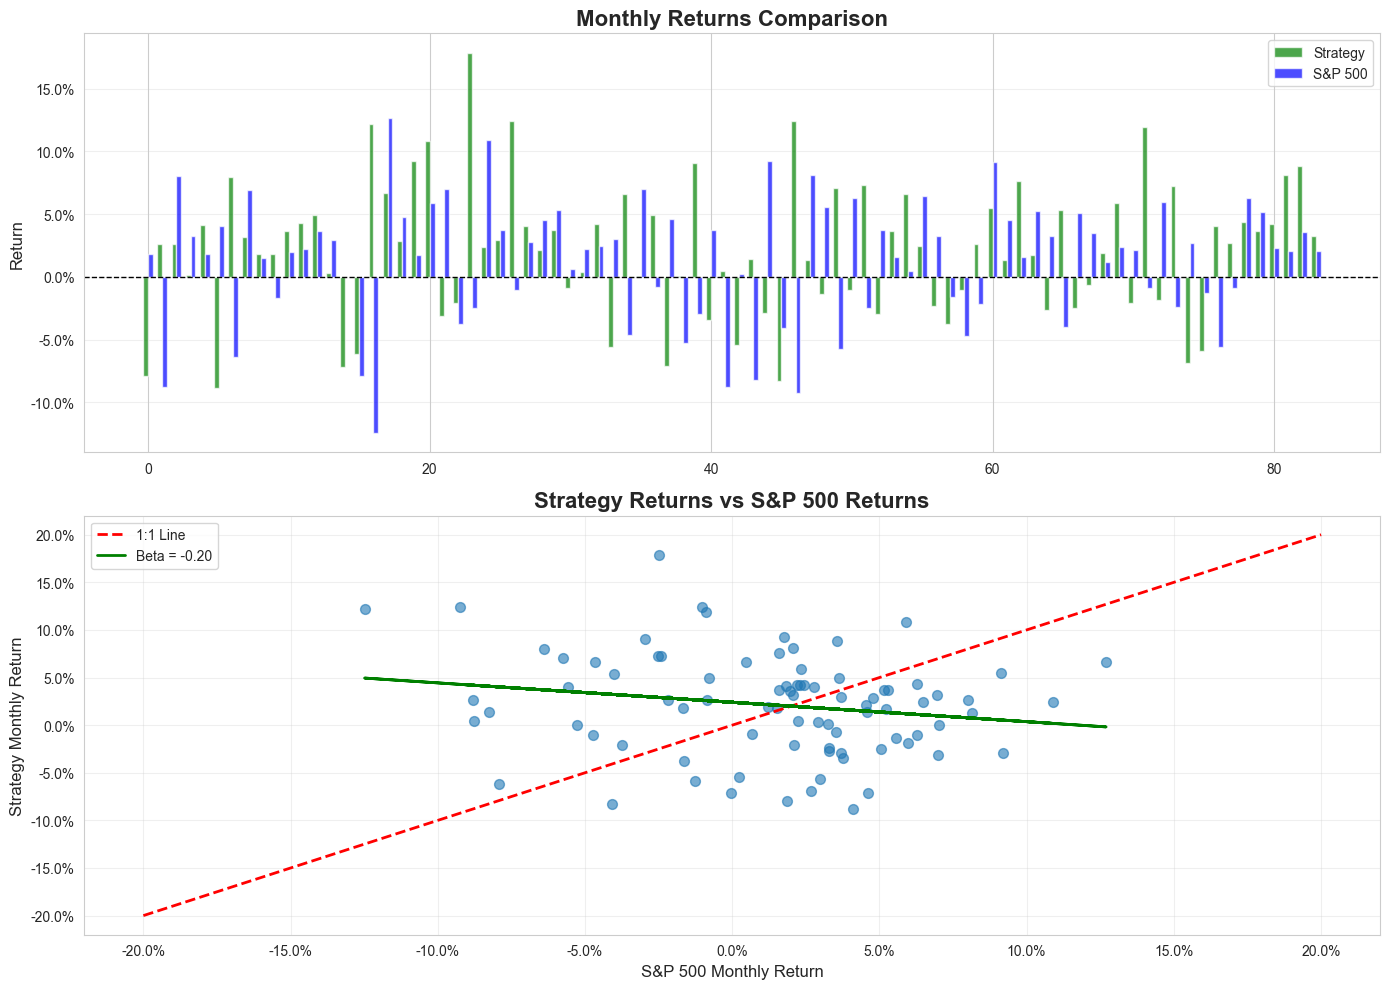

Correlation with S&P 500: -0.187
Beta: -0.204


In [28]:
# Monthly returns comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Bar chart comparison
x = np.arange(len(common_dates))
width = 0.35

axes[0].bar(x - width/2, strategy_returns, width, label='Strategy', alpha=0.7, color='green')
axes[0].bar(x + width/2, benchmark_returns, width, label='S&P 500', alpha=0.7, color='blue')
axes[0].set_title('Monthly Returns Comparison', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Return', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)

# Scatter plot
axes[1].scatter(benchmark_returns, strategy_returns, alpha=0.6, s=50)
axes[1].plot([-0.2, 0.2], [-0.2, 0.2], 'r--', linewidth=2, label='1:1 Line')

# Add regression line
z = np.polyfit(benchmark_returns, strategy_returns, 1)
p = np.poly1d(z)
axes[1].plot(benchmark_returns, p(benchmark_returns), "g-", linewidth=2, label=f'Beta = {z[0]:.2f}')

axes[1].set_title('Strategy Returns vs S&P 500 Returns', fontsize=16, fontweight='bold')
axes[1].set_xlabel('S&P 500 Monthly Return', fontsize=12)
axes[1].set_ylabel('Strategy Monthly Return', fontsize=12)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation and beta
correlation = strategy_returns.corr(benchmark_returns)
beta = strategy_returns.cov(benchmark_returns) / benchmark_returns.var()
print(f"Correlation with S&P 500: {correlation:.3f}")
print(f"Beta: {beta:.3f}")

In [29]:
# Win rate analysis
months_both_positive = ((strategy_returns > 0) & (benchmark_returns > 0)).sum()
months_both_negative = ((strategy_returns < 0) & (benchmark_returns < 0)).sum()
months_strategy_wins = ((strategy_returns > 0) & (benchmark_returns < 0)).sum()
months_benchmark_wins = ((strategy_returns < 0) & (benchmark_returns > 0)).sum()

print(f"\n{'='*80}")
print("MONTHLY WIN/LOSS ANALYSIS")
print(f"{'='*80}")
print(f"Both positive: {months_both_positive} months ({months_both_positive/len(common_dates)*100:.1f}%)")
print(f"Both negative: {months_both_negative} months ({months_both_negative/len(common_dates)*100:.1f}%)")
print(f"Strategy wins (S&P 500 loses): {months_strategy_wins} months ({months_strategy_wins/len(common_dates)*100:.1f}%)")
print(f"S&P 500 wins (Strategy loses): {months_benchmark_wins} months ({months_benchmark_wins/len(common_dates)*100:.1f}%)")

# Outperformance rate
outperform_months = (strategy_returns > benchmark_returns).sum()
print(f"\nMonths strategy outperformed: {outperform_months}/{len(common_dates)} ({outperform_months/len(common_dates)*100:.1f}%)")


MONTHLY WIN/LOSS ANALYSIS
Both positive: 37 months (44.0%)
Both negative: 7 months (8.3%)
Strategy wins (S&P 500 loses): 21 months (25.0%)
S&P 500 wins (Strategy loses): 19 months (22.6%)

Months strategy outperformed: 42/84 (50.0%)


### Why Compare to S&P 500?

The S&P 500 (SPY) represents a **passive buy-and-hold strategy**. Our goal is to generate **alpha** (excess returns) through:
- Active stock selection (momentum within clusters)
- Dynamic rebalancing (monthly)
- Systematic diversification (across cluster types)

**Key Questions:**
- Do we beat the benchmark on a risk-adjusted basis?
- Is our Sharpe ratio higher?
- What's the correlation? (Lower = more diversification benefit)
- Do we outperform in both up and down markets?

## 4. Equity Curve

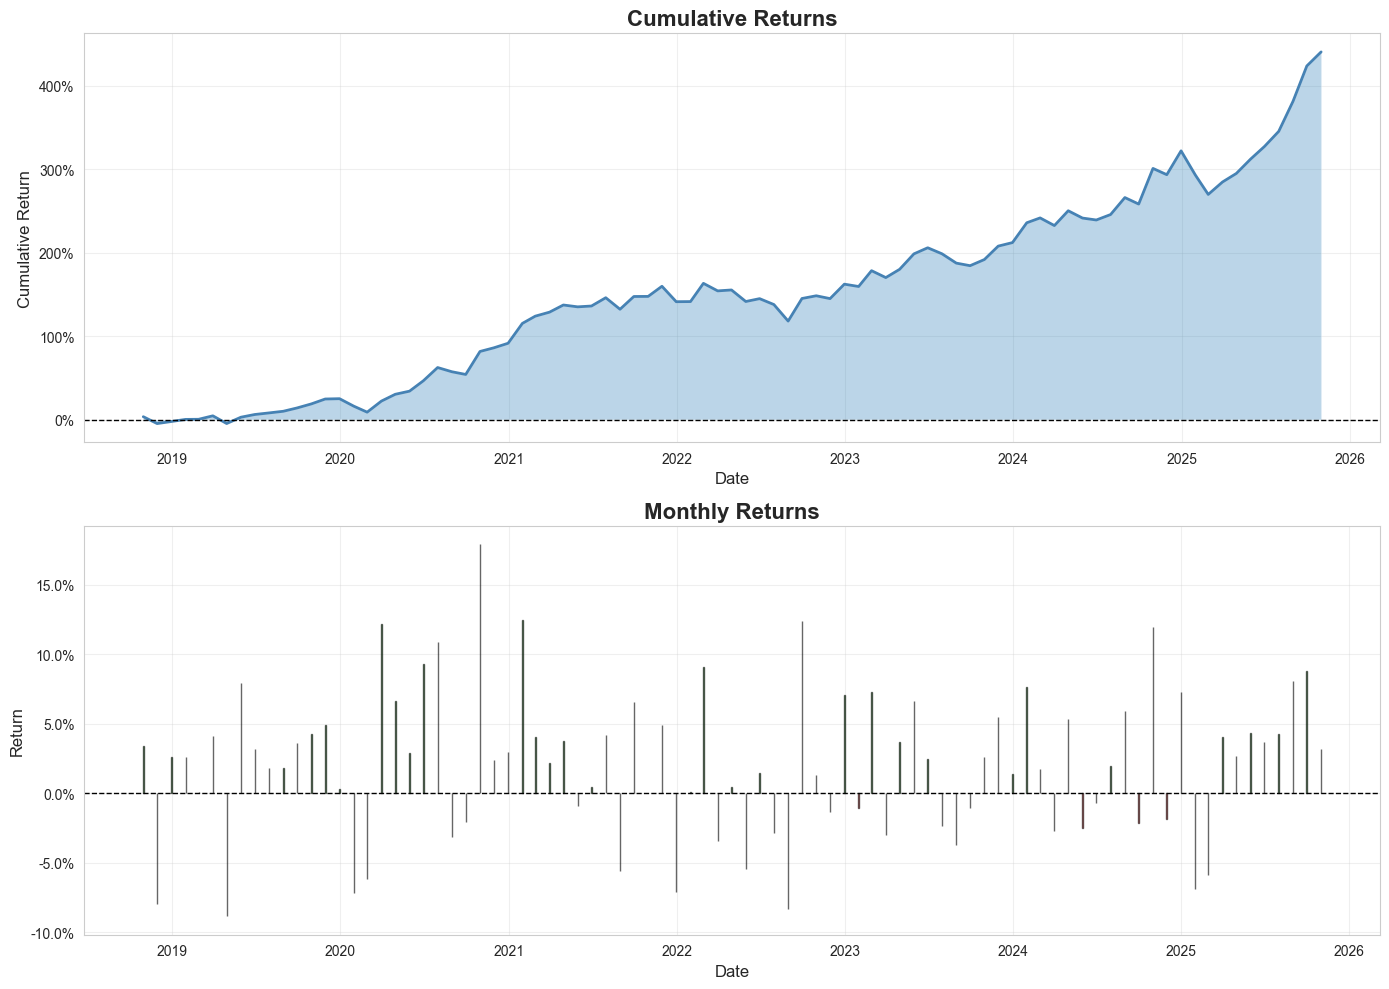

Final Cumulative Return: 440.22%


In [30]:
# Calculate cumulative returns
results['cumulative_return'] = (1 + results['portfolio_return']).cumprod() - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Equity curve
axes[0].plot(results.index, results['cumulative_return'], linewidth=2, color='steelblue')
axes[0].fill_between(results.index, 0, results['cumulative_return'], alpha=0.3)
axes[0].set_title('Cumulative Returns', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Cumulative Return', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)

# Monthly returns
colors = ['green' if x > 0 else 'red' for x in results['portfolio_return']]
axes[1].bar(results.index, results['portfolio_return'], color=colors, alpha=0.6, edgecolor='black')
axes[1].set_title('Monthly Returns', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Return', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

print(f"Final Cumulative Return: {results['cumulative_return'].iloc[-1]:.2%}")

## 5. Drawdown Analysis

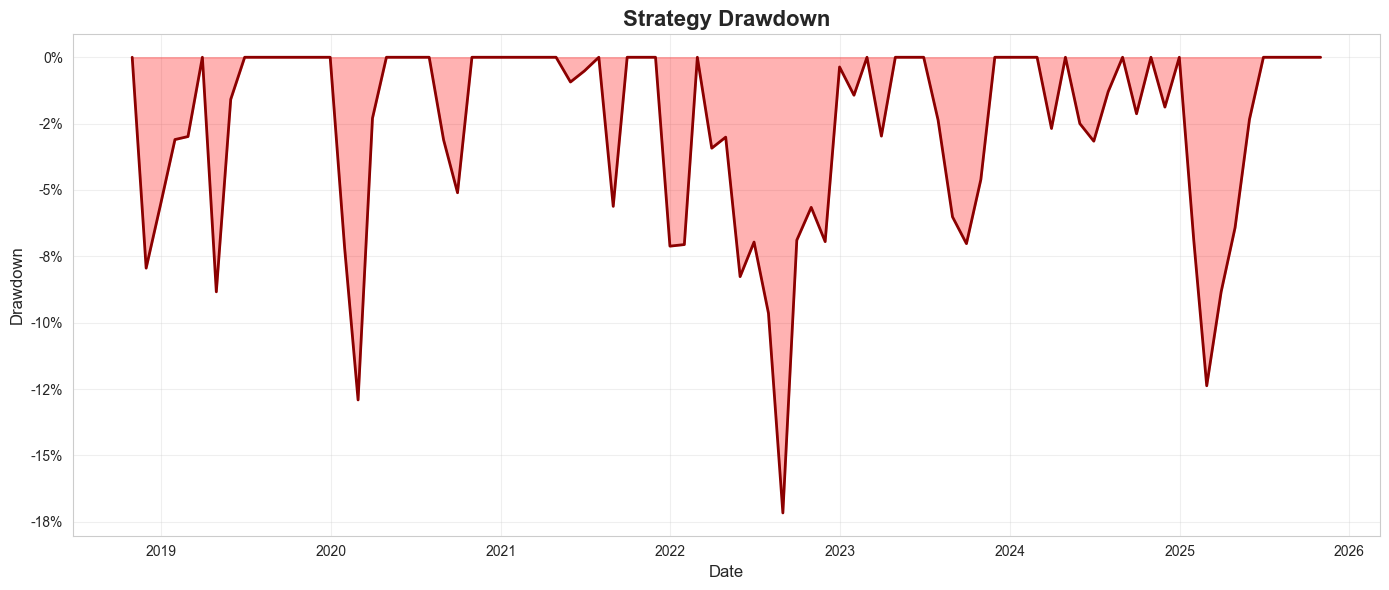

Max Drawdown: -17.17%
Current Drawdown: 0.00%


In [31]:
# Calculate drawdowns
cumulative_wealth = 1 + results['cumulative_return']
running_max = cumulative_wealth.expanding().max()
drawdown = (cumulative_wealth - running_max) / running_max

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(drawdown.index, 0, drawdown, color='red', alpha=0.3)
ax.plot(drawdown.index, drawdown, color='darkred', linewidth=2)
ax.set_title('Strategy Drawdown', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max Drawdown: {drawdown.min():.2%}")
print(f"Current Drawdown: {drawdown.iloc[-1]:.2%}")

## 6. Rolling Metrics

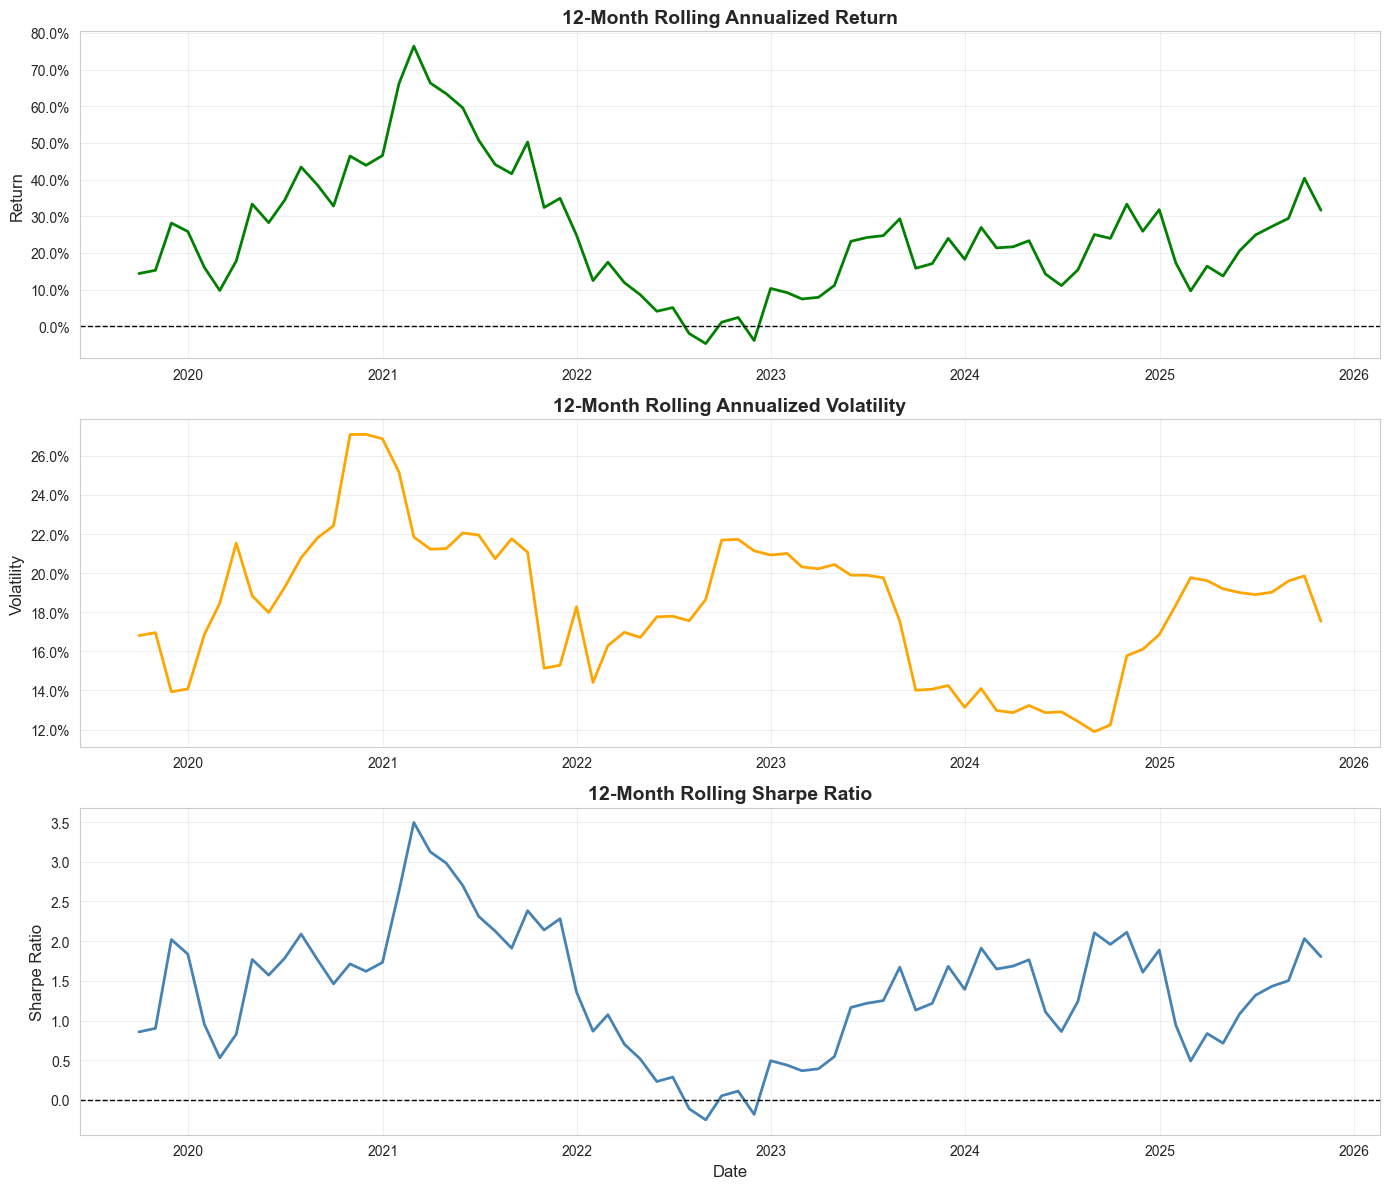

In [32]:
# Rolling 12-month metrics
window = 12

rolling_return = results['portfolio_return'].rolling(window).mean() * 12
rolling_vol = results['portfolio_return'].rolling(window).std() * np.sqrt(12)
rolling_sharpe = rolling_return / rolling_vol

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Rolling return
axes[0].plot(rolling_return.index, rolling_return, linewidth=2, color='green')
axes[0].set_title(f'{window}-Month Rolling Annualized Return', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Return', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)

# Rolling volatility
axes[1].plot(rolling_vol.index, rolling_vol, linewidth=2, color='orange')
axes[1].set_title(f'{window}-Month Rolling Annualized Volatility', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatility', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[1].grid(alpha=0.3)

# Rolling Sharpe
axes[2].plot(rolling_sharpe.index, rolling_sharpe, linewidth=2, color='steelblue')
axes[2].set_title(f'{window}-Month Rolling Sharpe Ratio', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Sharpe Ratio', fontsize=12)
axes[2].grid(alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## 7. Position Analysis

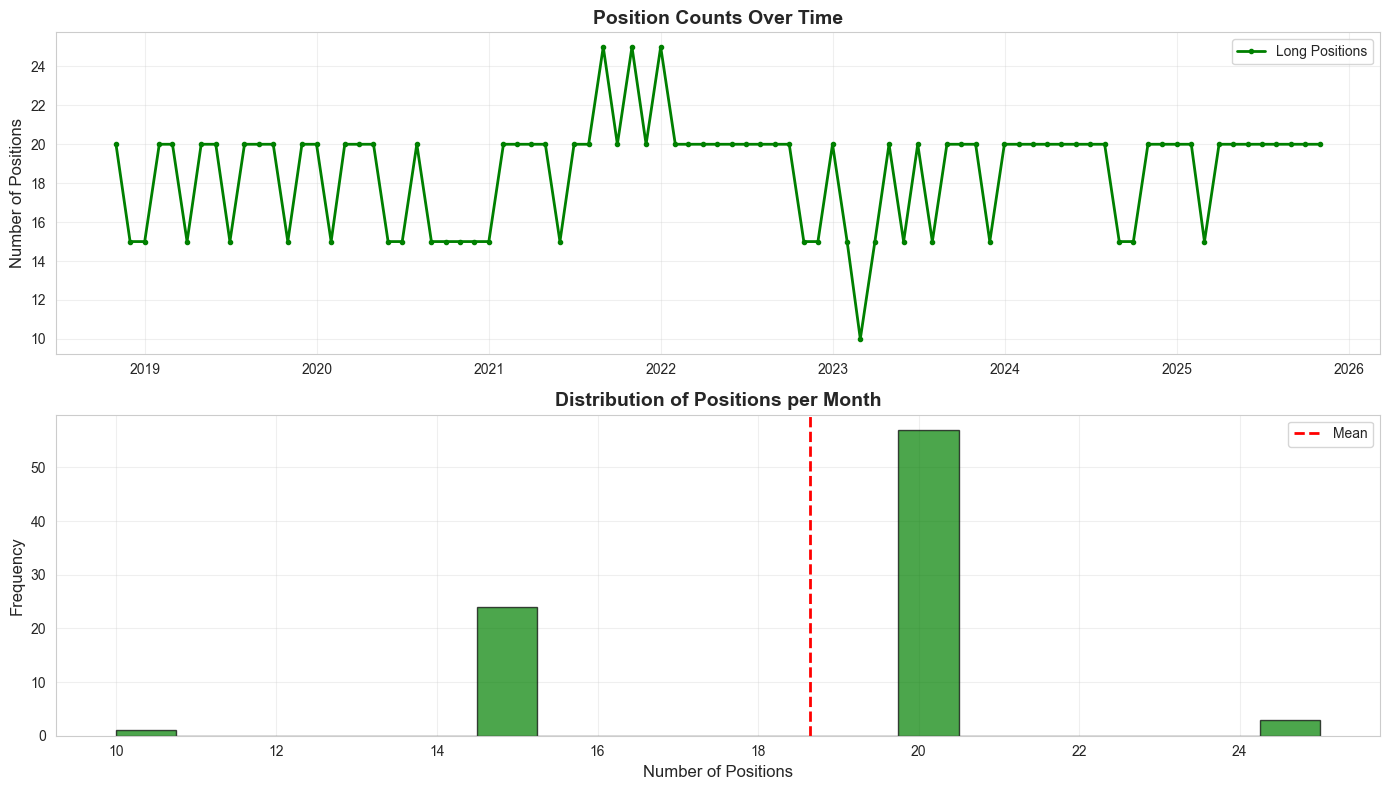

Average positions per month: 18.6
Min positions: 10
Max positions: 25


In [33]:
# Number of positions over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Position counts over time
axes[0].plot(results.index, results['n_positions'], label='Long Positions', linewidth=2, marker='o', markersize=3, color='green')
axes[0].set_title('Position Counts Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Positions', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution
axes[1].hist(results['n_positions'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Distribution of Positions per Month', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Positions', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(results['n_positions'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average positions per month: {results['n_positions'].mean():.1f}")
print(f"Min positions: {results['n_positions'].min():.0f}")
print(f"Max positions: {results['n_positions'].max():.0f}")

## 8. Position Returns Distribution

POSITION STATISTICS
  Mean return per position: 2.11%
  Median return per position: 1.65%
  Win rate: 56.01%
  Best position: 63.06%
  Worst position: -63.14%


C:\Users\15126\AppData\Local\Temp\ipykernel_37388\875191209.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(cluster_returns, labels=sorted(positions['cluster'].unique()))


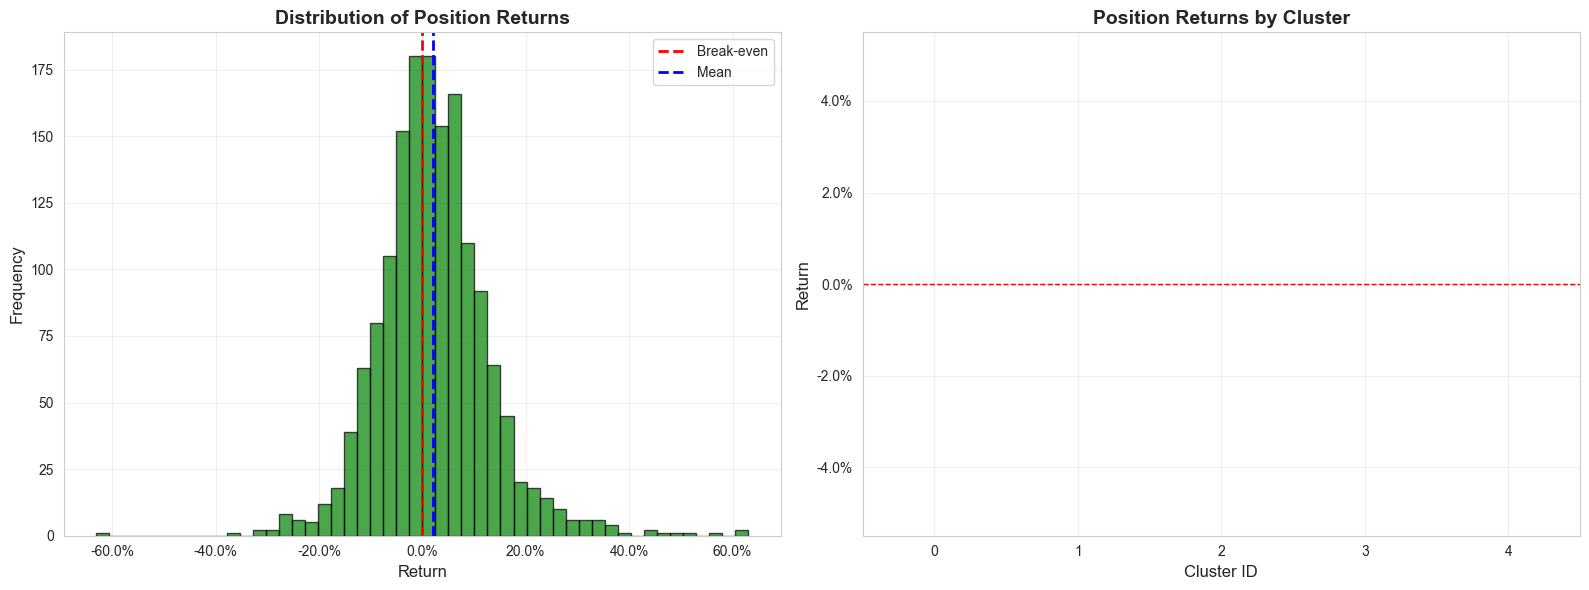

In [34]:
# Analyze individual position returns
positions['pnl'] = positions['forward_return_1m']

print("POSITION STATISTICS")
print(f"  Mean return per position: {positions['pnl'].mean():.2%}")
print(f"  Median return per position: {positions['pnl'].median():.2%}")
print(f"  Win rate: {(positions['pnl'] > 0).mean():.2%}")
print(f"  Best position: {positions['pnl'].max():.2%}")
print(f"  Worst position: {positions['pnl'].min():.2%}")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(positions['pnl'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even')
axes[0].axvline(positions['pnl'].mean(), color='blue', linestyle='--', linewidth=2, label='Mean')
axes[0].set_title('Distribution of Position Returns', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Return', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot by cluster
cluster_returns = [positions[positions['cluster'] == c]['pnl'] for c in sorted(positions['cluster'].unique())]
axes[1].boxplot(cluster_returns, labels=sorted(positions['cluster'].unique()))
axes[1].set_title('Position Returns by Cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster ID', fontsize=12)
axes[1].set_ylabel('Return', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Most Traded Stocks

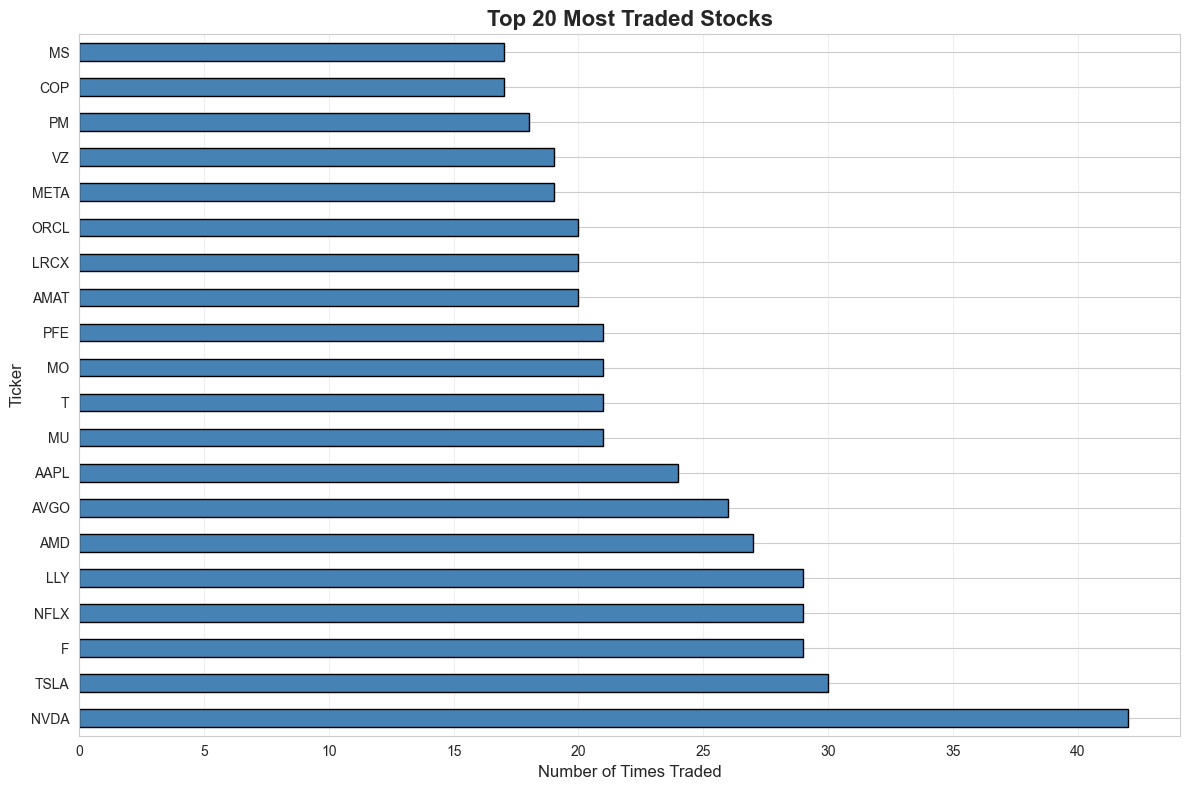


Top 10 Most Traded Stocks:
Ticker
NVDA    42
TSLA    30
F       29
NFLX    29
LLY     29
AMD     27
AVGO    26
AAPL    24
MU      21
T       21
Name: count, dtype: int64


In [35]:
# Count how often each stock was traded
ticker_counts = positions.index.get_level_values('Ticker').value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
ticker_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 20 Most Traded Stocks', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Times Traded', fontsize=12)
ax.set_ylabel('Ticker', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Traded Stocks:")
print(ticker_counts.head(10))

## 10. Best and Worst Trades

In [36]:
# Best and worst positions (pnl already calculated above)

# Best trades
print("TOP 10 BEST TRADES")
print("="*80)
best_trades = positions.nlargest(10, 'pnl')[['cluster', 'return_3m', 'forward_return_1m', 'pnl']]
print(best_trades.to_string())

print("\n\nTOP 10 WORST TRADES")
print("="*80)
worst_trades = positions.nsmallest(10, 'pnl')[['cluster', 'return_3m', 'forward_return_1m', 'pnl']]
print(worst_trades.to_string())

TOP 10 BEST TRADES
                   cluster  return_3m  forward_return_1m       pnl
Date       Ticker                                                 
2020-07-31 TSLA          0   0.223138           0.630608  0.630608
2024-10-31 PLTR          4   0.156187           0.614052  0.614052
2019-12-31 TSLA          0   0.202021           0.555160  0.555160
2025-07-31 WDC           0   0.137689           0.527510  0.527510
2020-03-31 TSLA          0   0.077964           0.492137  0.492137
2020-06-30 AMD           0   0.049742           0.471773  0.471773
2022-09-30 SLB           3   0.002842           0.449304  0.449304
2021-09-30 TSLA          2   0.044923           0.436530  0.436530
2025-03-31 PLTR          1   0.037248           0.403318  0.403318
2025-08-31 MU            4   0.080392           0.366318  0.366318


TOP 10 WORST TRADES
                   cluster  return_3m  forward_return_1m       pnl
Date       Ticker                                                 
2024-05-31 MRNA      

## 11. Cluster Contribution

PERFORMANCE BY CLUSTER
         mean_pnl  total_pnl  n_trades  win_rate
cluster                                         
3        0.032782   9.277248       283  0.600000
0        0.019037   7.614722       400  0.555556
2        0.022371   6.196904       277  0.550877
4        0.023116   5.640230       244  0.556000
1        0.012195   4.561077       374  0.544737


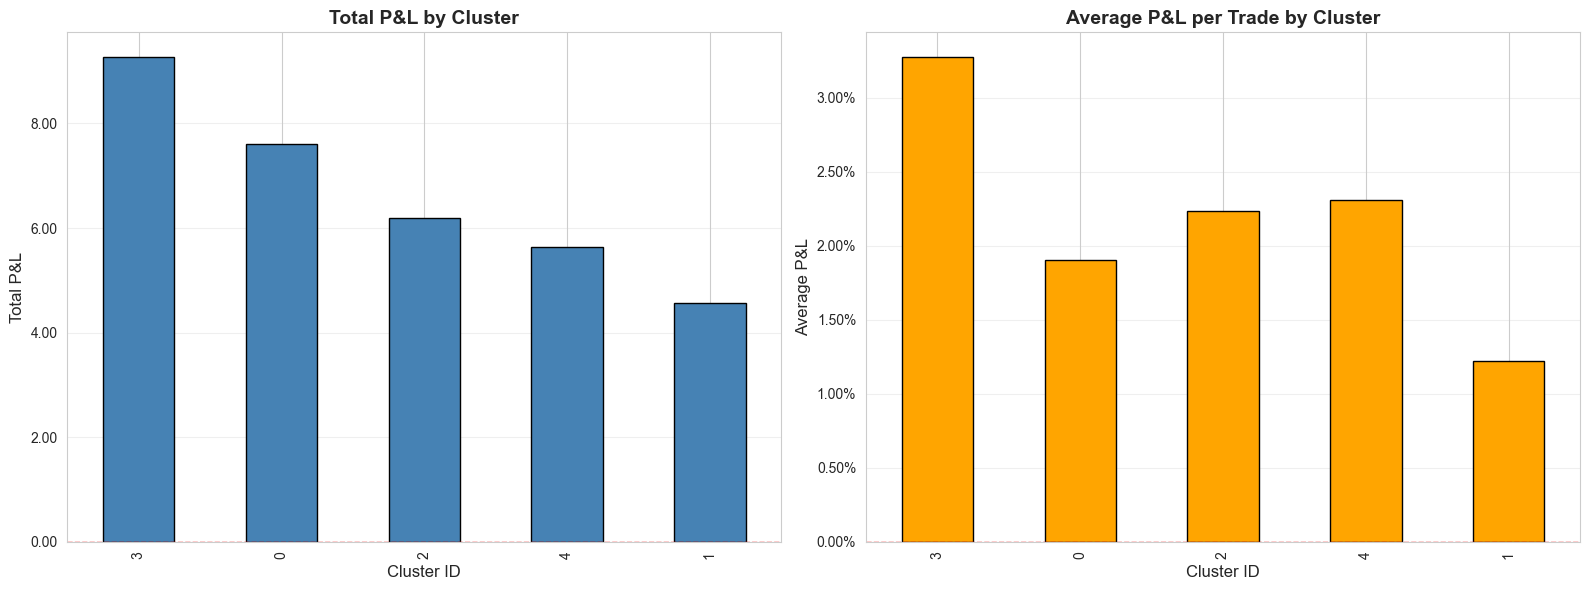

In [38]:
# Performance by cluster
cluster_perf = positions.groupby('cluster').agg({
    'pnl': ['mean', 'sum', 'count'],
})

cluster_perf.columns = ['mean_pnl', 'total_pnl', 'n_trades']
cluster_perf['win_rate'] = positions.groupby('cluster')['pnl'].apply(lambda x: (x > 0).mean())
cluster_perf = cluster_perf.sort_values('total_pnl', ascending=False)

print("PERFORMANCE BY CLUSTER")
print("="*80)
print(cluster_perf.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total PnL by cluster
cluster_perf['total_pnl'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total P&L by Cluster', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster ID', fontsize=12)
axes[0].set_ylabel('Total P&L', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)

# Average PnL by cluster
cluster_perf['mean_pnl'].plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Average P&L per Trade by Cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster ID', fontsize=12)
axes[1].set_ylabel('Average P&L', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2%}'))
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## 12. Parameter Testing

Test different momentum signals and position sizes.

### Understanding the Clusters

Each cluster represents stocks with similar characteristics:
- **Cluster 0:** Might be high-beta growth stocks
- **Cluster 1:** Might be defensive, low-volatility names  
- **Cluster 2:** Might be mid-cap value stocks
- **Cluster 3:** Might be momentum leaders
- **Cluster 4:** Might be large-cap stable names

The beauty of K-Means is that **clusters adapt each month** to current market conditions. The groupings aren't fixed - they evolve as correlations and characteristics change.

### Strategy Rationale

**Why cluster before ranking?**
- Comparing Tesla to Walmart directly doesn't make sense
- Different stocks have different risk/return profiles
- Clustering creates "apples-to-apples" comparisons

**Why momentum within clusters?**
- Momentum is well-documented in academic literature
- Works better within homogeneous groups
- Reduces noise from sector/factor rotations

**Why long-only?**
- Shorting is expensive (borrow costs, margin)
- Short positions often drag down performance
- Long-only is simpler and more implementable

Testing different parameter combinations...

Testing: return_1m, top 3 per cluster

BACKTESTING LONG-ONLY MOMENTUM WITHIN CLUSTERS
Momentum signal: return_1m
Long top 3 stocks per cluster

Calculating forward returns...
Generating trading signals...
Calculating portfolio returns...
Testing: return_1m, top 5 per cluster

BACKTESTING LONG-ONLY MOMENTUM WITHIN CLUSTERS
Momentum signal: return_1m
Long top 5 stocks per cluster

Calculating forward returns...
Generating trading signals...
Calculating portfolio returns...
Testing: return_1m, top 7 per cluster

BACKTESTING LONG-ONLY MOMENTUM WITHIN CLUSTERS
Momentum signal: return_1m
Long top 7 stocks per cluster

Calculating forward returns...
Generating trading signals...
Calculating portfolio returns...
Testing: return_1m, top 10 per cluster

BACKTESTING LONG-ONLY MOMENTUM WITHIN CLUSTERS
Momentum signal: return_1m
Long top 10 stocks per cluster

Calculating forward returns...
Generating trading signals...
Calculating portfolio returns...
T

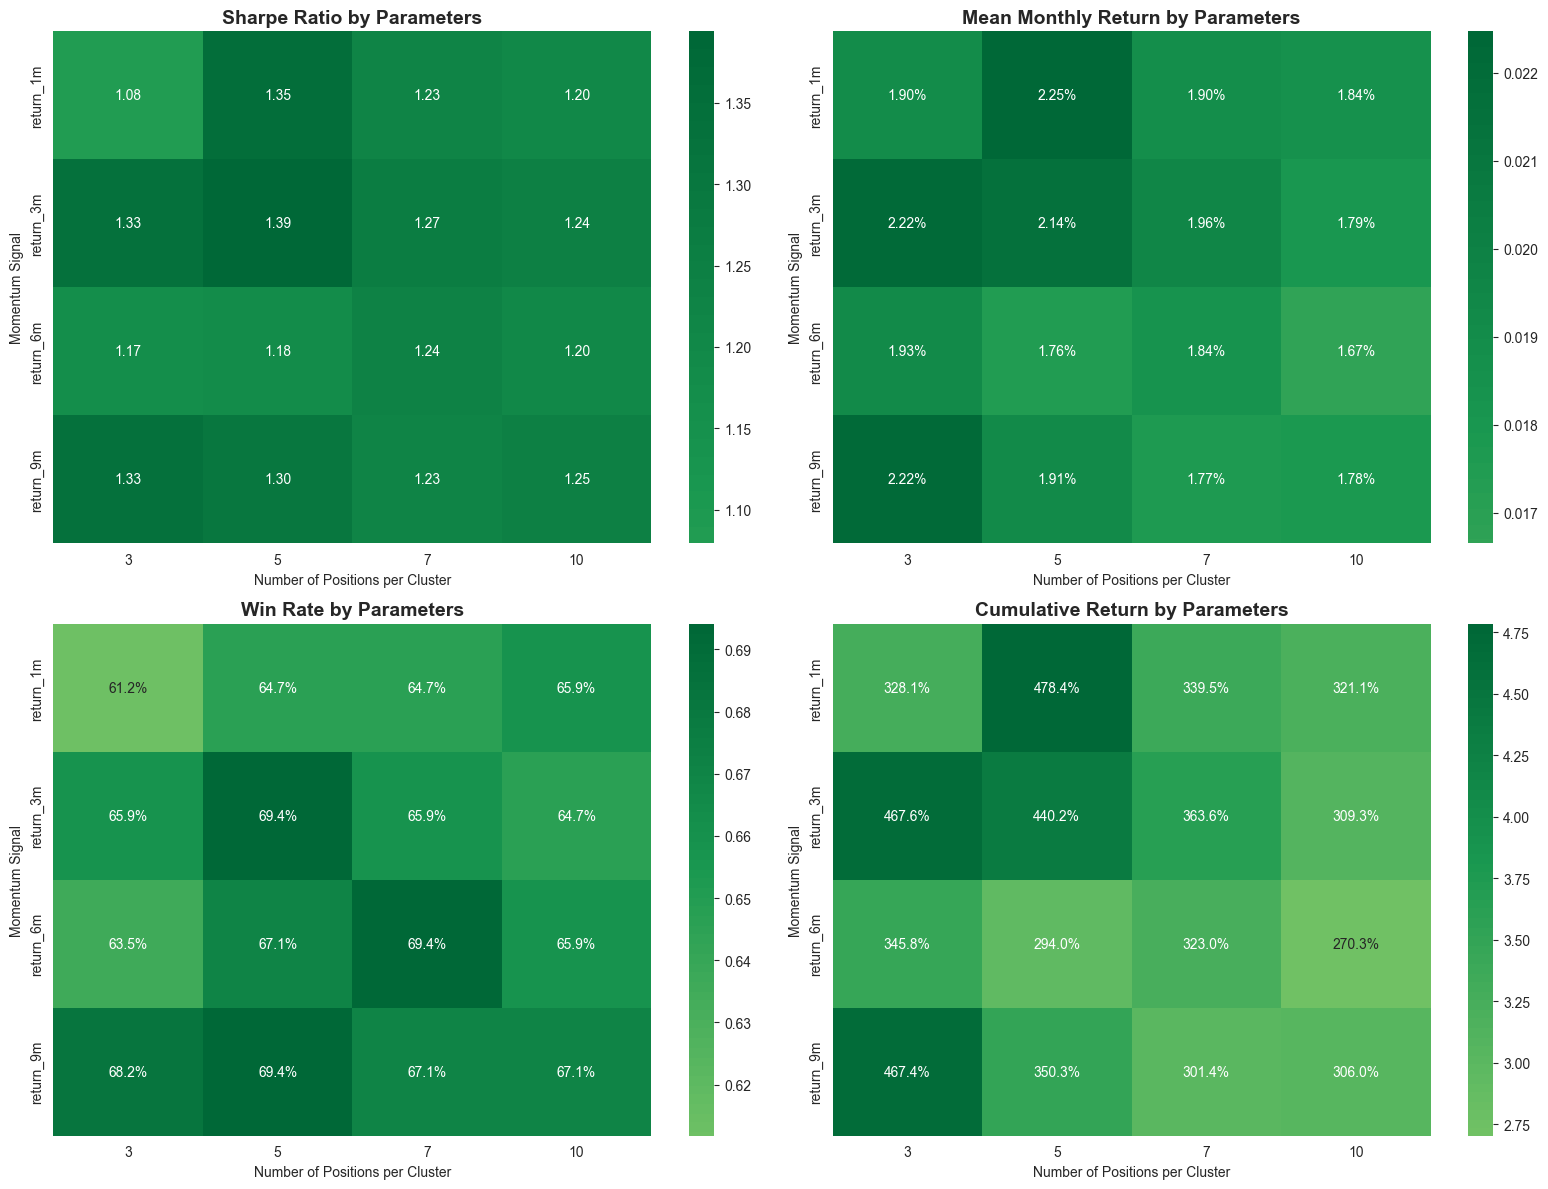


✓ Best configuration:
  Momentum: return_3m
  Positions per cluster: 5
  Sharpe Ratio: 1.39
  Mean Return: 2.14%


In [39]:
# Load original clustered data
clustered_data = pd.read_csv(data_dir / f'clustered_{method}.csv', parse_dates=['Date'])
clustered_data = clustered_data.set_index(['Date', 'Ticker']).sort_index()

# Test different parameters
param_results = []

momentum_features = ['return_1m', 'return_3m', 'return_6m', 'return_9m']
position_sizes = [3, 5, 7, 10]

print("Testing different parameter combinations...\n")

for momentum in momentum_features:
    for n_positions in position_sizes:
        print(f"Testing: {momentum}, top {n_positions} per cluster")
        
        results_test, _ = backtest_long_only(
            data=clustered_data.copy(),
            momentum_feature=momentum,
            top_n=n_positions,
        )
        
        returns = results_test['portfolio_return'].dropna()
        
        param_results.append({
            'momentum': momentum,
            'n_positions': n_positions,
            'mean_return': returns.mean(),
            'sharpe': returns.mean() / returns.std() * np.sqrt(12),
            'win_rate': (returns > 0).mean(),
            'cumulative': (1 + returns).prod() - 1,
        })

param_df = pd.DataFrame(param_results)
param_df = param_df.sort_values('sharpe', ascending=False)

print("\n" + "="*80)
print("PARAMETER COMPARISON (sorted by Sharpe Ratio)")
print("="*80)
print(param_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sharpe ratio heatmap
pivot_sharpe = param_df.pivot(index='momentum', columns='n_positions', values='sharpe')
sns.heatmap(pivot_sharpe, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[0,0])
axes[0,0].set_title('Sharpe Ratio by Parameters', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Number of Positions per Cluster')
axes[0,0].set_ylabel('Momentum Signal')

# Mean return heatmap
pivot_return = param_df.pivot(index='momentum', columns='n_positions', values='mean_return')
sns.heatmap(pivot_return, annot=True, fmt='.2%', cmap='RdYlGn', center=0, ax=axes[0,1])
axes[0,1].set_title('Mean Monthly Return by Parameters', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Number of Positions per Cluster')
axes[0,1].set_ylabel('Momentum Signal')

# Win rate heatmap
pivot_win = param_df.pivot(index='momentum', columns='n_positions', values='win_rate')
sns.heatmap(pivot_win, annot=True, fmt='.1%', cmap='RdYlGn', center=0.5, ax=axes[1,0])
axes[1,0].set_title('Win Rate by Parameters', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Positions per Cluster')
axes[1,0].set_ylabel('Momentum Signal')

# Cumulative return heatmap
pivot_cum = param_df.pivot(index='momentum', columns='n_positions', values='cumulative')
sns.heatmap(pivot_cum, annot=True, fmt='.1%', cmap='RdYlGn', center=0, ax=axes[1,1])
axes[1,1].set_title('Cumulative Return by Parameters', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Number of Positions per Cluster')
axes[1,1].set_ylabel('Momentum Signal')

plt.tight_layout()
plt.show()

print(f"\n✓ Best configuration:")
best = param_df.iloc[0]
print(f"  Momentum: {best['momentum']}")
print(f"  Positions per cluster: {best['n_positions']:.0f}")
print(f"  Sharpe Ratio: {best['sharpe']:.2f}")
print(f"  Mean Return: {best['mean_return']:.2%}")

## 13. Save Analysis Report

In [40]:
# Create a summary report
report = {
    'Strategy': 'Long-Only Momentum Within Clusters',
    'Clustering Method': method,
    'Total Months': len(results),
    'Mean Monthly Return': results['portfolio_return'].mean(),
    'Annualized Return': results['portfolio_return'].mean() * 12,
    'Volatility (Annual)': results['portfolio_return'].std() * np.sqrt(12),
    'Sharpe Ratio': results['portfolio_return'].mean() / results['portfolio_return'].std() * np.sqrt(12),
    'Win Rate': (results['portfolio_return'] > 0).mean(),
    'Max Drawdown': drawdown.min(),
    'Cumulative Return': results['cumulative_return'].iloc[-1],
    'Avg Positions per Month': results['n_positions'].mean(),
    'Total Trades': len(positions),
    'Trade Win Rate': (positions['pnl'] > 0).mean(),
}

report_df = pd.DataFrame([report]).T
report_df.columns = ['Value']

print("\nSTRATEGY REPORT SUMMARY")
print("="*80)
print(report_df.to_string())

# Save to file
report_df.to_csv(data_dir / f'long_only_report_{method}.csv')
print(f"\n✓ Report saved to long_only_report_{method}.csv")


STRATEGY REPORT SUMMARY
                                                      Value
Strategy                 Long-Only Momentum Within Clusters
Clustering Method                                    kmeans
Total Months                                             85
Mean Monthly Return                                0.021411
Annualized Return                                  0.256931
Volatility (Annual)                                0.184354
Sharpe Ratio                                       1.393683
Win Rate                                           0.694118
Max Drawdown                                      -0.171677
Cumulative Return                                  4.402224
Avg Positions per Month                           18.647059
Total Trades                                           1605
Trade Win Rate                                     0.560125

✓ Report saved to long_only_report_kmeans.csv
